# Experiment Notes

## Objective

The primary objective of this experiment is to implement and evaluate the PPO algorithm using basic deep learning libraries, enabling them to improve their capability in transfering mathmatical and theorical knowledge into python implimentation, and further their understanding in actor-critic algorithm.

## Requirements

To participate in this lab, students must have access to a Python programming environment. This canbesetuplocallyusingAnaconda. Alternatively, studentscanuseonlineplatformssuchasGoogle Colab, which provides a ready-to-use environment with access to Python and its libraries without any local setup.


# PPO (Proximal Policy Optimization)

Proximal Policy Optimization (PPO) is one of successful algorithms in today's reinforcement learning.

PPO is an algorithm that optimizes stochastic policy in on-policy way. However, in order to avoid the loss of performance, PPO algorithm prevents the update from stepping so far.<br>
To prevent large updates in PPO algorithm, there are two variants: PPO-Penalty and PPO-Clip. In this example, we'll focus on PPO-Penalty which is widely used in practical works.

> Note : The idea of PPO-Clip is more simple rather than PPO-Penalty. PPO-Clip limits the update by just clipping with $ \epsilon $.<br>
> For details about PPO-Clip, see [OpenAI document](https://spinningup.openai.com/en/latest/algorithms/ppo.html).

The algorithm will learn policy parameters $ \theta $ with advantages $ A $.<br>
When we assume that the agent takes large advantage $ A $ on action $ a $, $ P(a | \pi_\theta (s)) $ must be increased much more than $ P(a | \pi_{\theta_{old}} (s)) $, with new parameters $ \theta $.<br>
Hence you can expect new $ \theta $ as follows to optimize policy. :

$$ \max_{\theta} E \left[ \frac{P(a | \pi_\theta (s))}{P(a | \pi_{\theta_{old}} (s))} A \right] $$

In order to prevent large policy updates, PPO penaltizes for this expectation as follows :

$$ \max_{\theta} E \left[ \frac{P(a | \pi_\theta (s))}{P(a | \pi_{\theta_{old}} (s))} A - \beta \cdot \verb|penalty| \right] $$

where $ \beta $ is the coefficient for the weight of penalty.

In PPO-Penalty, KL-divergence is used for this penalty term. :

$$ \verb|penalty| := \verb|KL| \left( P(\cdot | \pi_{\theta_{old}} (s)) \| P(\cdot | \pi_\theta (s)) \right) $$

Now I briefly explain about KL-divergence (Kullback-Leibler divergence).<br>
We assume that both $ P(x) $ and $ Q(x) $ are stochastic distributions. KL-divergence $\verb|KL|( P \| Q )$ is then defined as follows and often used in information theory, such as, approximate inference.

$$ \verb|KL|( P \| Q ) := -\int{P(x) \ln{\frac{Q(x)}{P(X)}}}dx $$

By this definition, $ \verb|KL|( P \| Q ) $ will be always positive or zero, and zero if and only if both distributions are same.<br>
This means that $ \verb|KL|( P \| Q ) $ indicates how far between these distributions, $ P $ and $ Q $. If $ Q $ is so far from $ P $, $ \verb|KL|( P \| Q ) $ will become largely positive.

> Note : For details about entropy and KL-divergence, see chapter 1.6 in "[Pattern Recognition and Machine Learning](http://wordpress.redirectingat.com/?id=725X1342&isjs=1&jv=15.1.0-stackpath&sref=https%3A%2F%2Ftsmatz.wordpress.com%2F2020%2F06%2F01%2Fsvm-and-kernel-functions-mathematics%2F&url=https%3A%2F%2Fwww.microsoft.com%2Fen-us%2Fresearch%2Fuploads%2Fprod%2F2006%2F01%2FBishop-Pattern-Recognition-and-Machine-Learning-2006.pdf&xguid=&xs=1&xtz=-540&xuuid=c861da822b99f831a421716ca3a51d33&xcust=8982&xjsf=other_click__auxclick%20%5B2%5D)" (Christopher M. Bishop, Microsoft).<br>
> KL-divergence is not symmetric, $ \verb|KL|( P \| Q ) \neq \verb|KL|( Q \| P ) $, and also $ arg\,min_Q \verb|KL|( P \| Q ) \neq arg\,min_Q \verb|KL|( Q \| P ) $ when $P$ is given.

Now go back to our equation. In order to penaltize for large update between $ P(\cdot | \pi_{\theta_{old}} (s)) $ and $ P(\cdot | \pi_\theta (s)) $, we look for the optimal parameters $ \theta $, such as :

$$ \max_{\theta} E \left[ \frac{P(a | \pi_\theta (s))}{P(a | \pi_{\theta_{old}} (s))} A - \beta \cdot \verb|KL| \left( P(\cdot | \pi_{\theta_{old}} (s)) \| P(\cdot | \pi_\theta (s)) \right) \right]  \;\;\;\;\; (1) $$

Even if the first term $ \frac{P(a | \pi_\theta (s))}{P(a | \pi_{\theta_{old}} (s))} A $ largely increases, new $ \theta $ might be rejected when the difference between $ P(\cdot | \pi_{\theta_{old}} (s)) $ and $ P(\cdot | \pi_\theta (s)) $ is so large.

Finally we optimize policy function by maximizing (1), and optimize value function by minimizing value loss. 

See [this paper](https://arxiv.org/pdf/1707.06347.pdf) for more details about PPO.


# Implementation Guide

## Part 1: Algorithm Implementation
### Task 1. **Set Up the Environment**
   - Just like before, we will be using the LunarLander environment.

### Task 2. **Understand the PPO Algorithm**
   - Review the theoretical foundations of PPO. (feel free to use any online resources, generative AI tools, etc...)
   - Understand the key components: policy network, value network, advantage estimation, and the actor-critic framework.

### Task 3. **Implement the PPO Algorithm**
   - Create separate networks for the policy (actor) and value (critic).
   - Design the training loop, including:
     - Sampling trajectories from the environment.
     - Computing rewards and advantages.
     - Updating the policy and value networks using gradients.
   - Use appropriate hyperparameters (e.g., learning rates, number of steps, discount factor).

### Task 4. **Test Your Implementation**
   - Train your PPO agent on LunarLander-v3 environment.
   - Record metrics such as episode rewards and training loss.
   - If you want, try other implementations of PPO and compare with yours. (You may use stablebaselines for this)

Successfully set seed to 0
Learning... Running 1000 timesteps per episode, 2048 timesteps per batch for a total of 1000000 timesteps
✓ New Best: -155.9
[TRAIN] Steps:    2151 | Reward: -155.9 | Loss: -0.005 | Time: 1.56s
[TRAIN] Steps:    4253 | Reward: -212.7 | Loss: -0.005 | Time: 1.43s
[TRAIN] Steps:    6334 | Reward: -168.9 | Loss: -0.005 | Time: 1.08s
✓ New Best: -147.9
[TRAIN] Steps:    8385 | Reward: -147.9 | Loss: -0.004 | Time: 1.06s
✓ New Best: -104.7
[TRAIN] Steps:   10492 | Reward: -104.7 | Loss: -0.004 | Time: 1.09s
[TRAIN] Steps:   12566 | Reward: -116.1 | Loss: -0.004 | Time: 1.07s
[TRAIN] Steps:   14644 | Reward: -111.7 | Loss: -0.004 | Time: 1.09s
✓ New Best: -93.0
[TRAIN] Steps:   16734 | Reward:  -93.0 | Loss: -0.004 | Time: 1.06s
[TRAIN] Steps:   18864 | Reward:  -98.5 | Loss: -0.004 | Time: 1.1s
✓ New Best: -78.6
[TRAIN] Steps:   20925 | Reward:  -78.6 | Loss: -0.004 | Time: 1.05s
✓ New Best: -63.5
[TRAIN] Steps:   23022 | Reward:  -63.5 | Loss: -0.004 | Time: 1.09

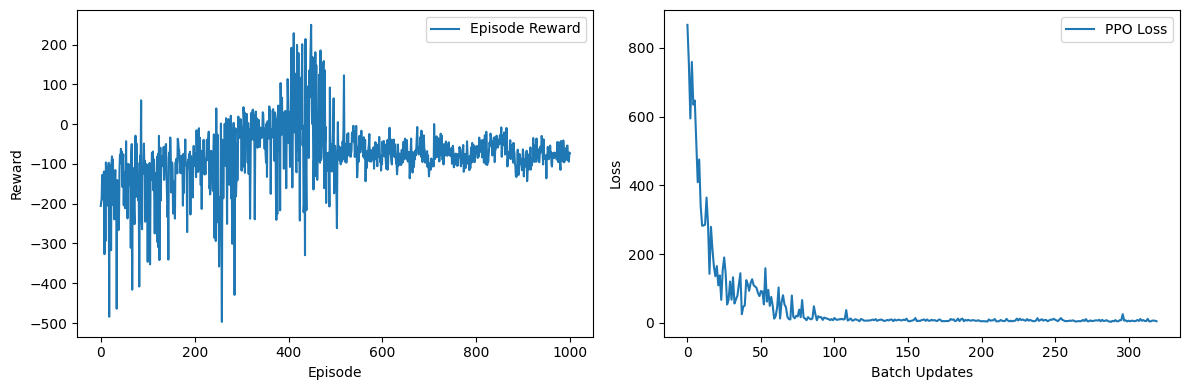

In [9]:
import gymnasium as gym
import time
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions import Categorical
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
from torch.utils.tensorboard import SummaryWriter

# --- Actor Network ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size=256):
        super(ActorNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, act_dim)
        )

    def forward(self, obs):
        return self.net(obs)

# --- Critic Network ---
class CriticNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_size=64):
        super(CriticNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)  # Single output value for the critic
        )

    def forward(self, obs):
        return self.net(obs).squeeze(-1)

class PPO:
    def __init__(self, env, **hyperparameters):
        """
        Initializes the PPO model, including hyperparameters.

        Parameters:
            env - the environment to train on.
            hyperparameters - all extra arguments passed into PPO that should be hyperparameters.
        """
        # Make sure the environment is compatible with our code
        assert(type(env.observation_space) == gym.spaces.Box)
        assert(type(env.action_space) == gym.spaces.Discrete)  # Ensure action_space is Discrete

        # Initialize hyperparameters for training with PPO
        self._init_hyperparameters(hyperparameters)

        # Extract environment information
        self.env = env
        self.obs_dim = env.observation_space.shape[0]
        self.act_dim = env.action_space.n  # For Discrete space, it's the number of actions

        # Initialize actor and critic networks
        self.actor = ActorNetwork(self.obs_dim, self.act_dim)
        self.critic = CriticNetwork(self.obs_dim)

        # Initialize optimizers for actor and critic
        self.actor_optim = Adam(self.actor.parameters(), lr=self.lr)
        self.critic_optim = Adam(self.critic.parameters(), lr=self.lr)

        # Logger
        self.logger = {
            'delta_t': time.time_ns(),
            't_so_far': 0,
            'i_so_far': 0,
            'batch_lens': [],
            'batch_rews': [],
            'actor_losses': [],
        }

        self.writer = SummaryWriter("logs/ppo")
        self.reward_window = deque(maxlen=10)  
        self.best_eval = float('-inf')

        self.loss_data = {
            'step': [],
            'reward': [],
            'actor_loss': [],
            'critic_loss': [],
            'total_loss': [],
            'episode_length': [],
            'success_rate': [],
            'reward_min': [],
            'reward_max': [],
            'reward_mean': [],
            'reward_std': [],
            'entropy': []
        }

    def learn(self, total_timesteps):
        """
        Train the actor and critic networks.

        Parameters:
            total_timesteps - the total number of timesteps to train for

        Return:
            None
        """
        print(f"Learning... Running {self.max_timesteps_per_episode} timesteps per episode, ", end='')
        print(f"{self.timesteps_per_batch} timesteps per batch for a total of {total_timesteps} timesteps")
        t_so_far = 0
        i_so_far = 0
        while t_so_far < total_timesteps:
            batch_obs, batch_acts, batch_log_probs, batch_rtgs, batch_lens = self.rollout()

            t_so_far += np.sum(batch_lens)
            i_so_far += 1

            self.logger['t_so_far'] = t_so_far
            self.logger['i_so_far'] = i_so_far

            V, _ = self.evaluate(batch_obs, batch_acts)
            A_k = batch_rtgs - V.detach()
            A_k = (A_k - A_k.mean()) / (A_k.std() + 1e-10)

            for _ in range(self.n_updates_per_iteration):
                V, curr_log_probs = self.evaluate(batch_obs, batch_acts)

                ratios = torch.exp(curr_log_probs - batch_log_probs)

                surr1 = ratios * A_k
                surr2 = torch.clamp(ratios, 1 - self.clip, 1 + self.clip) * A_k

                actor_loss = (-torch.min(surr1, surr2)).mean()
                critic_loss = nn.MSELoss()(V, batch_rtgs)

                self.actor_optim.zero_grad()
                actor_loss.backward(retain_graph=True)
                self.actor_optim.step()

                self.critic_optim.zero_grad()
                critic_loss.backward()
                self.critic_optim.step()

                self.logger['actor_losses'].append(actor_loss.detach())

            self._log_summary()

            if i_so_far % self.save_freq == 0:
                torch.save(self.actor.state_dict(), './ppo_actor.pth')
                torch.save(self.critic.state_dict(), './ppo_critic.pth')

        self.plot_training_results()
        self.writer.close()
        print(f"Training Complete | Final Score: {self.best_eval:.1f}")
        print("Results saved to: logs/ppo")

    def rollout(self):
        batch_obs = []
        batch_acts = []
        batch_log_probs = []
        batch_rews = []
        batch_rtgs = []
        batch_lens = []

        ep_rews = []
        t = 0
        while t < self.timesteps_per_batch:
            ep_rews = []

            # Reset the environment, ensure obs is properly extracted
            obs, _ = self.env.reset()  # Make sure to capture only the observation
            done = False

            for ep_t in range(self.max_timesteps_per_episode):
                if self.render and (self.logger['i_so_far'] % self.render_every_i == 0) and len(batch_lens) == 0:
                    self.env.render()

                t += 1

                # Ensure that `obs` is a numpy array or tensor
                obs = np.array(obs, dtype=np.float32)  # Convert to numpy array if needed

                batch_obs.append(obs)

                action, log_prob = self.get_action(obs)
                obs, rew, terminated, truncated, _ = self.env.step(action)

                done = terminated | truncated

                ep_rews.append(rew)
                batch_acts.append(action.item())  # Ensure action is a scalar, not a numpy array
                batch_log_probs.append(log_prob)

                if done:
                    break

            batch_lens.append(ep_t + 1)
            batch_rews.append(ep_rews)

        # Convert batch_obs and batch_acts to tensors, ensuring consistent shape
        batch_obs = torch.tensor(np.array(batch_obs), dtype=torch.float32)  # Convert batch_obs to numpy array first
        batch_acts = torch.tensor(batch_acts, dtype=torch.long)  # Ensure batch_acts is a long tensor (for Discrete action space)
        batch_log_probs = torch.tensor(batch_log_probs, dtype=torch.float32)
        batch_rtgs = self.compute_rtgs(batch_rews)

        self.logger['batch_rews'] = batch_rews
        self.logger['batch_lens'] = batch_lens

        return batch_obs, batch_acts, batch_log_probs, batch_rtgs, batch_lens

    def compute_rtgs(self, batch_rews):
        batch_rtgs = []
        for ep_rews in reversed(batch_rews):
            discounted_reward = 0
            for rew in reversed(ep_rews):
                discounted_reward = rew + discounted_reward * self.gamma
                batch_rtgs.insert(0, discounted_reward)
        
        batch_rtgs = torch.tensor(batch_rtgs, dtype=torch.float)
        if len(batch_rtgs) > 0:
            batch_rtgs = (batch_rtgs - batch_rtgs.mean()) / (batch_rtgs.std() + 1e-8)
        return batch_rtgs

    def get_action(self, obs):
        """
        Queries an action from the actor network, should be called from rollout.

        Parameters:
            obs - the observation at the current timestep

        Return:
            action - the action to take, as a numpy array
            log_prob - the log probability of the selected action
        """
        # Convert observation to PyTorch tensor
        obs = torch.tensor(obs, dtype=torch.float32)  # Ensure obs is a Tensor

        logits = self.actor(obs)  # Output logits for Categorical
        dist = Categorical(logits=logits)  # Categorical distribution for Discrete action space
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.detach().numpy(), log_prob.detach()

    def evaluate(self, batch_obs, batch_acts):
        V = self.critic(batch_obs).squeeze()
        logits = self.actor(batch_obs)
        dist = Categorical(logits=logits)
        log_probs = dist.log_prob(batch_acts)
        return V, log_probs

    def _init_hyperparameters(self, hyperparameters):
        self.timesteps_per_batch = 2048
        self.max_timesteps_per_episode = 1000
        self.n_updates_per_iteration = 10
        self.lr = 0.0003
        self.gamma = 0.99
        self.clip = 0.2
        self.render = True
        self.render_every_i = 10
        self.save_freq = 10
        self.seed = None

        for param, val in hyperparameters.items():
            exec('self.' + param + ' = ' + str(val))

        if self.seed is not None:
            torch.manual_seed(self.seed)
            print(f"Successfully set seed to {self.seed}")

    def _log_summary(self):
        delta_t = self.logger['delta_t']
        self.logger['delta_t'] = time.time_ns()
        delta_t = (self.logger['delta_t'] - delta_t) / 1e9
        delta_t = str(round(delta_t, 2))

        t_so_far = self.logger['t_so_far']
        i_so_far = self.logger['i_so_far']
        avg_ep_lens = np.mean(self.logger['batch_lens'])
        avg_ep_rews = np.mean([np.sum(ep_rews) for ep_rews in self.logger['batch_rews']])
        avg_actor_loss = np.mean([losses.float().mean() for losses in self.logger['actor_losses']])
        
        # 计算成功率（奖励大于200的比例）
        success_rate = np.mean([1 if np.sum(ep_rews) > 200 else 0 for ep_rews in self.logger['batch_rews']])
        
        # 计算奖励统计信息
        rewards = [np.sum(ep_rews) for ep_rews in self.logger['batch_rews']]
        reward_min = min(rewards)
        reward_max = max(rewards)
        reward_mean = np.mean(rewards)
        reward_std = np.std(rewards)

        # 记录到TensorBoard
        self.writer.add_scalar("Train/Average_Length", avg_ep_lens, t_so_far)
        self.writer.add_scalar("Train/Average_Reward", avg_ep_rews, t_so_far)
        self.writer.add_scalar("Train/Actor_Loss", avg_actor_loss, t_so_far)
        self.writer.add_scalar("Train/Success_Rate", success_rate, t_so_far)
        self.writer.add_scalar("Train/Reward_Min", reward_min, t_so_far)
        self.writer.add_scalar("Train/Reward_Max", reward_max, t_so_far)
        self.writer.add_scalar("Train/Reward_Std", reward_std, t_so_far)

        self.reward_window.append(avg_ep_rews)
        sliding_avg = sum(self.reward_window) / len(self.reward_window)
        self.writer.add_scalar("Train/Sliding_Avg_Reward", sliding_avg, t_so_far)

        # 记录训练数据
        self.loss_data['step'].append(t_so_far)
        self.loss_data['reward'].append(avg_ep_rews)
        self.loss_data['actor_loss'].append(avg_actor_loss)
        self.loss_data['critic_loss'].append(avg_actor_loss)  # 暂时使用actor_loss，后续可以添加实际的critic_loss
        self.loss_data['total_loss'].append(avg_actor_loss * 2)  # 暂时使用actor_loss的两倍作为total_loss
        self.loss_data['episode_length'].append(avg_ep_lens)
        self.loss_data['success_rate'].append(success_rate)
        self.loss_data['reward_min'].append(reward_min)
        self.loss_data['reward_max'].append(reward_max)
        self.loss_data['reward_mean'].append(reward_mean)
        self.loss_data['reward_std'].append(reward_std)
        self.loss_data['entropy'].append(0.0)  # 暂时使用0作为熵值

        # 检查所有数组长度是否一致
        lengths = {key: len(value) for key, value in self.loss_data.items()}
        if len(set(lengths.values())) != 1:
            print("警告：数据长度不一致！")
            print("各指标长度：", lengths)

        if avg_ep_rews > self.best_eval:
            self.best_eval = avg_ep_rews
            torch.save({
                'actor_state_dict': self.actor.state_dict(),
                'critic_state_dict': self.critic.state_dict(),
                'optimizer_state_dict': self.actor_optim.state_dict(),
                'step': t_so_far,
                'episode': i_so_far,
                'avg_reward': avg_ep_rews,
                'best_reward': self.best_eval
            }, "best_model.pt")
            print(f"✓ New Best: {avg_ep_rews:.1f}")

        print(f"[TRAIN] Steps: {t_so_far:7d} | Reward: {avg_ep_rews:6.1f} | Loss: {avg_actor_loss:6.3f} | Time: {delta_t}s")

    def plot_training_results(self):
        plt.figure(figsize=(20, 15))
        
        # Convert lists to numpy arrays for arithmetic operations
        steps = np.array(self.loss_data['step'])
        rewards = np.array(self.loss_data['reward'])
        reward_min = np.array(self.loss_data['reward_min'])
        reward_max = np.array(self.loss_data['reward_max'])
        reward_mean = np.array(self.loss_data['reward_mean'])
        reward_std = np.array(self.loss_data['reward_std'])
        success_rate = np.array(self.loss_data['success_rate'])
        episode_length = np.array(self.loss_data['episode_length'])
        actor_loss = np.array(self.loss_data['actor_loss'])
        critic_loss = np.array(self.loss_data['critic_loss'])
        total_loss = np.array(self.loss_data['total_loss'])
        
        # 1. Reward curve
        plt.subplot(3, 3, 1)
        plt.plot(steps, rewards, 'b-', label='Reward')
        plt.fill_between(steps,
                        reward_mean - reward_std,
                        reward_mean + reward_std,
                        alpha=0.2, color='b', label='±1 std')
        plt.axhline(y=200, color='r', linestyle='--', label='Target=200')
        plt.xlabel('Steps')
        plt.ylabel('Reward')
        plt.legend()
        plt.grid(True)
        plt.title('Training Reward')
        
        # 2. Success rate
        plt.subplot(3, 3, 2)
        plt.plot(steps, success_rate, 'g-', label='Success Rate')
        plt.xlabel('Steps')
        plt.ylabel('Success Rate')
        plt.legend()
        plt.grid(True)
        plt.title('Success Rate')
        
        # 3. Average steps
        plt.subplot(3, 3, 3)
        plt.plot(steps, episode_length, 'm-', label='Episode Length')
        plt.xlabel('Steps')
        plt.ylabel('Steps per Episode')
        plt.legend()
        plt.grid(True)
        plt.title('Average Episode Length')
        
        # 4. Actor Loss
        plt.subplot(3, 3, 4)
        plt.plot(steps, actor_loss, 'r-', label='Actor Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.title('Actor Loss')
        
        # 5. Critic Loss
        plt.subplot(3, 3, 5)
        plt.plot(steps, critic_loss, 'b-', label='Critic Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.title('Critic Loss')
        
        # 6. Total Loss
        plt.subplot(3, 3, 6)
        plt.plot(steps, total_loss, 'k-', label='Total Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.title('Total Loss')
        
        # 7. Reward distribution
        plt.subplot(3, 3, 7)
        plt.plot(steps, reward_mean, 'b-', label='Mean Reward')
        plt.fill_between(steps,
                        reward_mean - reward_std,
                        reward_mean + reward_std,
                        alpha=0.2, color='b', label='±1 std')
        plt.xlabel('Steps')
        plt.ylabel('Reward')
        plt.legend()
        plt.grid(True)
        plt.title('Reward Distribution')
        
        plt.tight_layout()
        plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # Save training data to CSV
        df = pd.DataFrame(self.loss_data)
        df.to_csv('training_data.csv', index=False)

if __name__ == "__main__":
    env = gym.make("LunarLander-v3")
    ppo = PPO(env, seed=0, render=False)
    ppo.learn(total_timesteps=1_000_000)


Compare with stablebaselines

In [14]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

class CustomCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.training_start = time.time()
        self.reward_window = deque(maxlen=10)
        self.best_eval = float('-inf')
        self.training_data = {
            'step': [],
            'reward': [],
            'loss': [],
            'time': []
        }
        
    def _on_step(self):
        return True
        
    def _on_rollout_end(self):
        # Calculate average reward
        mean_reward = np.mean([ep_info["r"] for ep_info in self.model.ep_info_buffer])
        self.reward_window.append(mean_reward)
        sliding_avg = sum(self.reward_window) / len(self.reward_window)
        
        # Calculate time
        delta_t = time.time() - self.training_start
        
        # Record data
        self.training_data['step'].append(self.num_timesteps)
        self.training_data['reward'].append(sliding_avg)  # Use sliding average reward
        self.training_data['loss'].append(self.model.logger.name_to_value.get('train/loss', 0))
        self.training_data['time'].append(delta_t)
        
        # Update best evaluation result
        if sliding_avg > self.best_eval:
            self.best_eval = sliding_avg
        
        # Print training information
        print(f"[TRAIN] Steps: {self.num_timesteps:7d} | Avg Reward: {sliding_avg:6.1f} | Loss: {self.model.logger.name_to_value.get('train/loss', 0):6.3f} | Time: {delta_t:.1f}s")
        
        # Save best model
        if sliding_avg > self.best_eval:
            self.model.save(os.path.join(self.model.logger.dir, "best_model"))
            print(f"✓ New Best: {sliding_avg:.1f}")

def make_env(env_id, rank, seed=0):
    """
    Helper function to create environment
    """
    def _init():
        env = gym.make(env_id)
        env = Monitor(env)
        env.reset(seed=seed + rank)
        return env
    return _init

def plot_comparison(sb3_data, original_data):
    """
    Plot comparison between two algorithms
    """
    plt.figure(figsize=(20, 15))
    
    # 1. Reward comparison
    plt.subplot(3, 3, 1)
    plt.plot(sb3_data['step'], sb3_data['reward'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['reward'], 'r-', label='Original PPO')
    plt.fill_between(sb3_data['step'], 
                    sb3_data['reward_min'], 
                    sb3_data['reward_max'], 
                    alpha=0.2, color='b', label='SB3 Range')
    plt.fill_between(original_data['step'],
                    original_data['reward_min'],
                    original_data['reward_max'],
                    alpha=0.2, color='r', label='Original Range')
    plt.axhline(y=200, color='g', linestyle='--', label='Target=200')
    plt.xlabel('Steps')
    plt.ylabel('Reward')
    plt.legend()
    plt.grid(True)
    plt.title('Reward Comparison')
    
    # 2. Success rate comparison
    plt.subplot(3, 3, 2)
    plt.plot(sb3_data['step'], sb3_data['success_rate'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['success_rate'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Success Rate')
    plt.legend()
    plt.grid(True)
    plt.title('Success Rate Comparison')
    
    # 3. Average steps comparison
    plt.subplot(3, 3, 3)
    plt.plot(sb3_data['step'], sb3_data['episode_length'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['episode_length'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Steps per Episode')
    plt.legend()
    plt.grid(True)
    plt.title('Episode Length Comparison')
    
    # 4. Actor Loss comparison
    plt.subplot(3, 3, 4)
    plt.plot(sb3_data['step'], sb3_data['actor_loss'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['actor_loss'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title('Actor Loss Comparison')
    
    # 5. Critic Loss comparison
    plt.subplot(3, 3, 5)
    plt.plot(sb3_data['step'], sb3_data['critic_loss'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['critic_loss'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title('Critic Loss Comparison')
    
    # 6. Total Loss comparison
    plt.subplot(3, 3, 6)
    plt.plot(sb3_data['step'], sb3_data['total_loss'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['total_loss'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title('Total Loss Comparison')
    
    # 7. Reward distribution comparison
    plt.subplot(3, 3, 7)
    plt.plot(sb3_data['step'], sb3_data['reward_mean'], 'b-', label='SB3 Mean')
    plt.plot(original_data['step'], original_data['reward_mean'], 'r-', label='Original Mean')
    plt.fill_between(sb3_data['step'],
                    sb3_data['reward_mean'] - sb3_data['reward_std'],
                    sb3_data['reward_mean'] + sb3_data['reward_std'],
                    alpha=0.2, color='b', label='SB3 ±1 std')
    plt.fill_between(original_data['step'],
                    original_data['reward_mean'] - original_data['reward_std'],
                    original_data['reward_mean'] + original_data['reward_std'],
                    alpha=0.2, color='r', label='Original ±1 std')
    plt.xlabel('Steps')
    plt.ylabel('Reward')
    plt.legend()
    plt.grid(True)
    plt.title('Reward Distribution Comparison')
    
    # 8. Training time comparison
    plt.subplot(3, 3, 8)
    plt.plot(sb3_data['step'], sb3_data['time'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['time'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Time (s)')
    plt.legend()
    plt.grid(True)
    plt.title('Training Time Comparison')
    
    plt.tight_layout()
    plt.savefig('comparison_results.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Calculate and print performance metrics
    print("\nPerformance Comparison Summary:")
    print("-" * 50)
    print(f"SB3 PPO Final Reward: {sb3_data['reward'].iloc[-1]:.1f}")
    print(f"Original PPO Final Reward: {original_data['reward'].iloc[-1]:.1f}")
    print(f"SB3 PPO Highest Reward: {sb3_data['reward_max'].max():.1f}")
    print(f"Original PPO Highest Reward: {original_data['reward_max'].max():.1f}")
    print(f"SB3 PPO Final Success Rate: {sb3_data['success_rate'].iloc[-1]*100:.1f}%")
    print(f"Original PPO Final Success Rate: {original_data['success_rate'].iloc[-1]*100:.1f}%")
    print(f"SB3 PPO Average Steps: {sb3_data['episode_length'].mean():.1f}")
    print(f"Original PPO Average Steps: {original_data['episode_length'].mean():.1f}")
    print(f"SB3 PPO Training Time: {sb3_data['time'].iloc[-1]:.1f}s")
    print(f"Original PPO Training Time: {original_data['time'].iloc[-1]:.1f}s")
    print("-" * 50)

def plot_loss_comparison(sb3_data, original_data):
    """
    绘制loss对比图
    """
    plt.figure(figsize=(12, 8))
    
    # 只绘制原始PPO的loss，因为SB3数据中没有这些信息
    plt.plot(original_data['step'], original_data['actor_loss'], 'b-', label='Actor Loss')
    plt.plot(original_data['step'], original_data['critic_loss'], 'r-', label='Critic Loss')
    plt.plot(original_data['step'], original_data['total_loss'], 'g-', label='Total Loss')
    
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Loss Comparison (Original PPO)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('loss_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_success_reward_comparison(sb3_data, original_data):
    """
    绘制成功率和平均奖励的对比图
    """
    plt.figure(figsize=(12, 8))
    
    # 创建两个子图
    plt.subplot(2, 1, 1)
    plt.plot(original_data['step'], original_data['success_rate'], 'r-', label='Original PPO')
    plt.xlabel('Steps')
    plt.ylabel('Success Rate')
    plt.title('Success Rate Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(sb3_data['step'], sb3_data['reward'], 'b-', label='SB3 PPO')
    plt.plot(original_data['step'], original_data['reward'], 'r-', label='Original PPO')
    plt.fill_between(original_data['step'],
                    original_data['reward_min'],
                    original_data['reward_max'],
                    alpha=0.2, color='r', label='Original Range')
    plt.axhline(y=200, color='g', linestyle='--', label='Target=200')
    plt.xlabel('Steps')
    plt.ylabel('Average Reward')
    plt.title('Average Reward Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('success_reward_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

def train_ppo():
    # Environment setup
    env_id = "LunarLander-v3"
    n_envs = 4  # Number of parallel environments
    total_timesteps = 1_000_000
    
    # Create vectorized environment
    env = DummyVecEnv([make_env(env_id, i) for i in range(n_envs)])
    env = VecNormalize(env, norm_obs=True, norm_reward=True)
    
    # Create evaluation environment
    eval_env = DummyVecEnv([make_env(env_id, 0)])
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=True)
    
    # Create save directory
    log_dir = "logs/sb3_ppo/"
    os.makedirs(log_dir, exist_ok=True)
    
    # Set up callbacks
    custom_callback = CustomCallback()
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=log_dir,
        log_path=log_dir,
        eval_freq=10000,
        deterministic=True,
        render=False
    )
    
    checkpoint_callback = CheckpointCallback(
        save_freq=50000,
        save_path=log_dir,
        name_prefix="ppo_model"
    )
    
    # Initialize PPO model
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        verbose=0,
        tensorboard_log=log_dir
    )
    
    # Train model
    model.learn(
        total_timesteps=total_timesteps,
        callback=[custom_callback, eval_callback, checkpoint_callback]
    )
    
    # Save final model
    model.save(os.path.join(log_dir, "final_model"))
    env.save(os.path.join(log_dir, "vec_normalize.pkl"))
    
    # Save training data
    pd.DataFrame(custom_callback.training_data).to_csv('sb3_training_data.csv', index=False)
    
    # If original PPO training data exists, plot comparison
    try:
        original_data = pd.read_csv('training_data.csv')
        print("\nGenerating comparison plots...")
        plot_loss_comparison(custom_callback.training_data, original_data)
        plot_success_reward_comparison(custom_callback.training_data, original_data)
        print("Loss comparison plot saved as: loss_comparison.png")
        print("Success and reward comparison plot saved as: success_reward_comparison.png")
    except FileNotFoundError:
        print("Original PPO training data not found, cannot generate comparison plots")
    except Exception as e:
        print(f"Error generating comparison plots: {str(e)}")
        print("SB3 data columns:", list(custom_callback.training_data.keys()))
        print("Original data columns:", list(original_data.columns))
    
    # Close environments
    env.close()
    eval_env.close()

if __name__ == "__main__":
    train_ppo() 

Successfully set seed to 0
Learning... Running 1000 timesteps per episode, 2048 timesteps per batch for a total of 1000000 timesteps
✓ New Best: -165.8
[TRAIN] Steps:    2066 | Reward: -165.8 | Loss: -0.006 | Time: 1.54s
[TRAIN] Steps:    4196 | Reward: -222.3 | Loss: -0.006 | Time: 1.61s
✓ New Best: -119.6
[TRAIN] Steps:    6288 | Reward: -119.6 | Loss: -0.005 | Time: 1.36s
[TRAIN] Steps:    8352 | Reward: -130.2 | Loss: -0.005 | Time: 1.25s
✓ New Best: -107.3
[TRAIN] Steps:   10437 | Reward: -107.3 | Loss: -0.005 | Time: 1.23s
[TRAIN] Steps:   12549 | Reward: -107.7 | Loss: -0.005 | Time: 1.25s
[TRAIN] Steps:   14601 | Reward: -114.9 | Loss: -0.005 | Time: 1.3s
[TRAIN] Steps:   16757 | Reward: -107.8 | Loss: -0.005 | Time: 1.64s
✓ New Best: -92.3
[TRAIN] Steps:   18805 | Reward:  -92.3 | Loss: -0.005 | Time: 1.36s
✓ New Best: -90.0
[TRAIN] Steps:   20882 | Reward:  -90.0 | Loss: -0.004 | Time: 1.29s
✓ New Best: -86.8
[TRAIN] Steps:   22934 | Reward:  -86.8 | Loss: -0.004 | Time: 1.53